# 04 – Reinforcement Learning Agent: Instagram Post Strategy Optimizer

**Project:** Reinforcement Learning for Instagram Post Strategy Optimization  
**Course:** MSDS 696 – Data Practicum II | Regis University

**This notebook covers:**
- Loading the trained engagement-prediction model from Notebook 03
- Defining a Q-Learning agent over a **48-action space** (4 hashtags × 4 time slots × 3 media types)
- Training the agent with epsilon-greedy exploration (500 episodes)
- Visualizing the learned Q-table as heatmaps
- Reporting the optimal **hashtag + time-of-day + media type** strategy (*what* AND *when* to post)

**Input:** `clustered_data.csv`, `model.pkl`, `encoder_maps.pkl`  
**Output:** Learned Q-table, optimal posting strategy recommendation  
**Note:** `media_type` (image / carousel / reel) has been added as a third action dimension so the agent now recommends *what to post* in addition to *when to post*.

## 1. Setup – Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import random

warnings.filterwarnings("ignore")
print("Libraries loaded.")

Libraries loaded.


## 2. Load Data, Model & Encoder Maps

In [2]:
# Load reference dataframe (used for cluster lookup inside reward function)
df = pd.read_csv("clustered_data.csv")

# Load trained RandomForestRegressor
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

# Load encoder / decoder maps saved in Notebook 03
with open("encoder_maps.pkl", "rb") as f:
    enc = pickle.load(f)

HASHTAG_ENCODER    = enc["HASHTAG_ENCODER"]
TIME_ENCODER       = enc["TIME_ENCODER"]
MEDIA_TYPE_ENCODER = enc["MEDIA_TYPE_ENCODER"]
HASHTAG_DECODER    = enc["HASHTAG_DECODER"]
TIME_DECODER       = enc["TIME_DECODER"]
MEDIA_TYPE_DECODER = enc["MEDIA_TYPE_DECODER"]

# Ensure encoded columns exist (needed by reward function)
df["hashtag_encoded"]    = df["hashtag"].map(HASHTAG_ENCODER)
df["time_encoded"]       = df["time_of_day"].map(TIME_ENCODER)
df["media_type_encoded"] = df["media_type"].map(MEDIA_TYPE_ENCODER)

print(f"Data loaded  : {df.shape[0]} rows")
print(f"Model        : {model}  (n_features={model.n_features_in_})")
print(f"\nHashtag map    : {HASHTAG_ENCODER}")
print(f"Time map       : {TIME_ENCODER}")
print(f"Media type map : {MEDIA_TYPE_ENCODER}")

Data loaded  : 16613 rows
Model        : RandomForestRegressor(n_jobs=-1, random_state=42)  (n_features=4)

Hashtag map    : {'#AppleEvent2025': 0, '#MadeByGoogle': 1, '#GalaxyS25': 2, '#GalaxyS25Edge': 3}
Time map       : {'morning': 0, 'afternoon': 1, 'evening': 2, 'night': 3}
Media type map : {'image': 0, 'carousel': 1, 'reel': 2}


## 3. Define the Environment

### State & Action Space

The RL environment is a **bandit-style** grid expanded to 3 dimensions:

| Dimension | Options | Count |
|-----------|---------|-------|
| Hashtag   | #AppleEvent2025, #MadeByGoogle, #GalaxyS25, #GalaxyS25Edge | 4 |
| Time of day | morning, afternoon, evening, night | 4 |
| Media type | image, carousel, reel | 3 |
| **Total states / actions** | | **48** |

- **State:** current (hashtag, time_of_day, media_type) selection
- **Action:** choose any of the 48 (hashtag, time_of_day, media_type) combinations
- **Reward:** predicted engagement returned by the supervised model
- **Transition:** `next_state = action` (the chosen combination becomes the new state)

In [3]:
N_HASHTAGS   = len(HASHTAG_ENCODER)       # 4
N_TIMES      = len(TIME_ENCODER)          # 4
N_MEDIA      = len(MEDIA_TYPE_ENCODER)    # 3
N_STATES     = N_HASHTAGS * N_TIMES * N_MEDIA   # 48
N_ACTIONS    = N_STATES                          # each action = pick one of the 48 combos

# All (hashtag_enc, time_enc, media_enc) combinations — index i is "action i"
ACTIONS = [
    (h, t, m)
    for h in range(N_HASHTAGS)
    for t in range(N_TIMES)
    for m in range(N_MEDIA)
]

def state_index(hashtag_enc: int, time_enc: int, media_enc: int) -> int:
    """Convert (hashtag_enc, time_enc, media_enc) triple to a flat state index 0-47."""
    return hashtag_enc * N_TIMES * N_MEDIA + time_enc * N_MEDIA + media_enc

def predict_engagement(hashtag_enc: int, time_enc: int, media_enc: int) -> float:
    """
    Reward function: predicted engagement for a (hashtag, time_of_day, media_type) triple.
    Uses the modal cluster seen in the reference dataset for that combination.
    """
    mask = (
        (df["hashtag_encoded"]    == hashtag_enc) &
        (df["time_encoded"]       == time_enc)    &
        (df["media_type_encoded"] == media_enc)
    )
    cluster_mode = int(df.loc[mask, "cluster"].mode()[0]) if mask.any() else 0
    return float(model.predict([[hashtag_enc, time_enc, media_enc, cluster_mode]])[0])

# Pre-compute a reward lookup table (48 values) — makes training faster
REWARD_TABLE = {
    (h, t, m): predict_engagement(h, t, m)
    for h in range(N_HASHTAGS)
    for t in range(N_TIMES)
    for m in range(N_MEDIA)
}

print(f"State space  : {N_STATES} states (4 hashtags × 4 time slots × 3 media types)")
print(f"Action space : {N_ACTIONS} actions")
print(f"\nReward table (predicted engagement):")
for (h, t, m), r in REWARD_TABLE.items():
    print(f"  {HASHTAG_DECODER[h]:<20} × {TIME_DECODER[t]:<12} × {MEDIA_TYPE_DECODER[m]:<10} → {r:.1f}")

State space  : 48 states (4 hashtags × 4 time slots × 3 media types)
Action space : 48 actions

Reward table (predicted engagement):
  #AppleEvent2025      × morning      × image      → 170.9
  #AppleEvent2025      × morning      × carousel   → 167.7
  #AppleEvent2025      × morning      × reel       → 164.7
  #AppleEvent2025      × afternoon    × image      → 173.1
  #AppleEvent2025      × afternoon    × carousel   → 169.2
  #AppleEvent2025      × afternoon    × reel       → 154.8
  #AppleEvent2025      × evening      × image      → 164.6
  #AppleEvent2025      × evening      × carousel   → 162.8
  #AppleEvent2025      × evening      × reel       → 159.6
  #AppleEvent2025      × night        × image      → 165.2
  #AppleEvent2025      × night        × carousel   → 162.5
  #AppleEvent2025      × night        × reel       → 166.3
  #MadeByGoogle        × morning      × image      → 161.4
  #MadeByGoogle        × morning      × carousel   → 166.1
  #MadeByGoogle        × morning      × r

## 4. Q-Learning Agent

### Hyperparameters

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `alpha` | 0.1 | Learning rate — how much new info overrides old |
| `gamma` | 0.9 | Discount factor — weight of future rewards |
| `epsilon` | 1.0 → 0.05 | Exploration rate (decays each episode) |
| `decay` | 0.995 | Epsilon decay multiplier per episode |
| `episodes` | 500 | Total training episodes |
| `steps` | 10 | Steps per episode |

Q-table shape is now **(48 × 48)** — one row per state, one column per action.

In [4]:
class QLearningAgent:
    """
    Tabular Q-Learning agent for Instagram post strategy optimization.

    Q-table shape: (N_STATES, N_ACTIONS) = (48, 48)
    Each entry Q[s, a] estimates the expected cumulative reward
    of taking action a from state s.
    Actions encode (hashtag, time_of_day, media_type) triples.
    """

    def __init__(
        self,
        n_states:   int   = N_STATES,
        n_actions:  int   = N_ACTIONS,
        alpha:      float = 0.1,
        gamma:      float = 0.9,
        epsilon:    float = 1.0,
        epsilon_min:float = 0.05,
        decay:      float = 0.995,
        seed:       int   = 42,
    ):
        self.n_states    = n_states
        self.n_actions   = n_actions
        self.alpha       = alpha
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.epsilon_min = epsilon_min
        self.decay       = decay

        rng = np.random.default_rng(seed)
        _ = rng  # ensures reproducibility even if numpy changes defaults
        random.seed(seed)
        np.random.seed(seed)

        # Q-table initialised to zero
        self.Q = np.zeros((n_states, n_actions))

    def choose_action(self, state: int) -> int:
        """Epsilon-greedy action selection."""
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)   # explore
        return int(np.argmax(self.Q[state]))                # exploit

    def update(self, state: int, action: int, reward: float, next_state: int) -> None:
        """Bellman update for Q(state, action)."""
        best_next = np.max(self.Q[next_state])
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error

    def decay_epsilon(self) -> None:
        """Decay epsilon after each episode (floor at epsilon_min)."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.decay)


agent = QLearningAgent()
print("Q-Learning agent created.")
print(f"Q-table shape : {agent.Q.shape}  (states × actions)")
print(f"Epsilon start : {agent.epsilon}")

Q-Learning agent created.
Q-table shape : (48, 48)  (states × actions)
Epsilon start : 1.0


## 5. Training Loop (500 Episodes)

In [5]:
EPISODES   = 500
STEPS      = 10

episode_rewards = []   # total reward per episode (for learning-curve plot)
epsilon_history = []   # epsilon per episode

for episode in range(EPISODES):
    # Random starting state
    start_action = random.randint(0, N_ACTIONS - 1)
    h0, t0, m0 = ACTIONS[start_action]
    state       = state_index(h0, t0, m0)

    total_reward = 0.0

    for _ in range(STEPS):
        action = agent.choose_action(state)

        # Unpack chosen (hashtag, time, media_type) combination
        h_enc, t_enc, m_enc = ACTIONS[action]

        # Reward = predicted engagement for this combination
        reward = REWARD_TABLE[(h_enc, t_enc, m_enc)]

        # Transition: next state IS the chosen action (bandit-style)
        next_state = state_index(h_enc, t_enc, m_enc)

        # Q-table update
        agent.update(state, action, reward, next_state)

        state        = next_state
        total_reward += reward

    agent.decay_epsilon()
    episode_rewards.append(total_reward / STEPS)   # avg reward per step
    epsilon_history.append(agent.epsilon)

print(f"Training complete — {EPISODES} episodes.")
print(f"Final epsilon : {agent.epsilon:.4f}")
print(f"Avg reward (last 50 eps) : {np.mean(episode_rewards[-50:]):.1f}")

Training complete — 500 episodes.
Final epsilon : 0.0816
Avg reward (last 50 eps) : 170.1


## 6. Visualizations

### 6.1 – Learning Curve (Reward & Epsilon over Episodes)

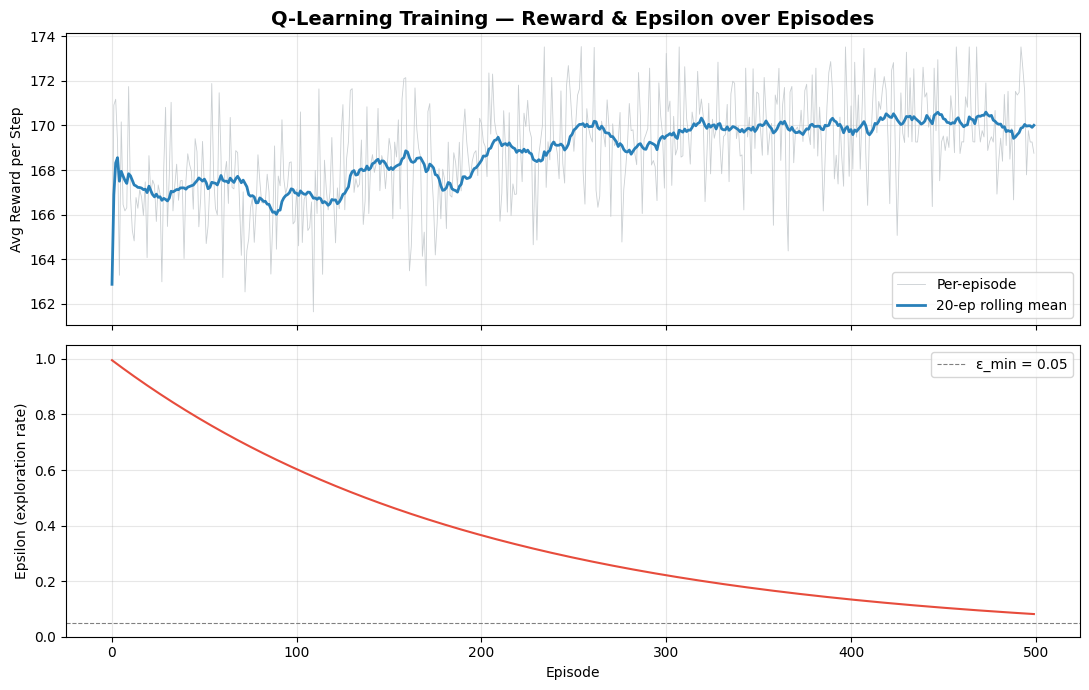

Saved: plot_12_learning_curve.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# --- Reward curve ---
window = 20
smooth = pd.Series(episode_rewards).rolling(window, min_periods=1).mean()
ax1.plot(episode_rewards, color="#BDC3C7", linewidth=0.6, alpha=0.8, label="Per-episode")
ax1.plot(smooth, color="#2980B9", linewidth=2, label=f"{window}-ep rolling mean")
ax1.set_ylabel("Avg Reward per Step")
ax1.set_title("Q-Learning Training — Reward & Epsilon over Episodes",
              fontsize=14, fontweight="bold")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# --- Epsilon decay ---
ax2.plot(epsilon_history, color="#E74C3C", linewidth=1.5)
ax2.set_ylabel("Epsilon (exploration rate)")
ax2.set_xlabel("Episode")
ax2.set_ylim(0, 1.05)
ax2.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="ε_min = 0.05")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot_12_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_12_learning_curve.png")

## 6.2 Q-Table Heatmaps

Because the action space is now 3-dimensional (hashtag × time × media type), we slice the learned Q-table into **three heatmaps** — one per media type.

Each cell shows the **maximum Q-value** the agent learned for that (hashtag, time) pair **under that media type**, i.e. the expected cumulative engagement when that specific combination is used.  
Brighter colours = higher expected reward.

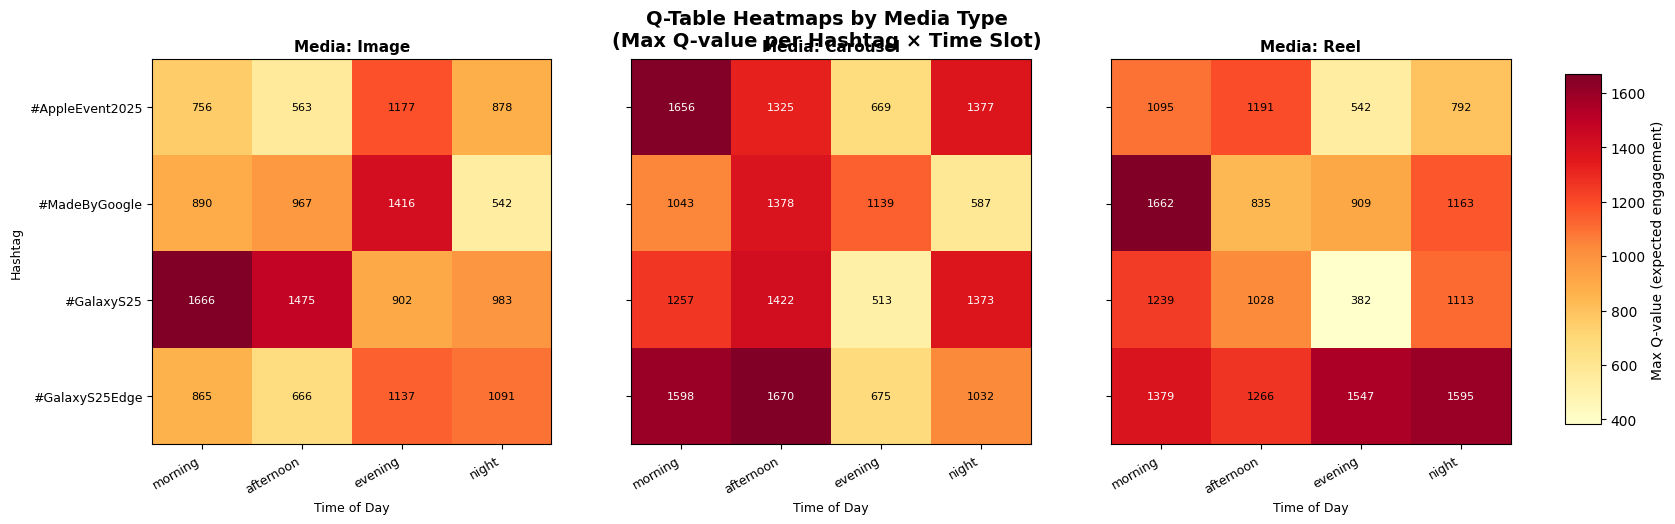

Heatmap saved → q_table_heatmaps.png


In [7]:
hashtag_labels    = [HASHTAG_DECODER[h]    for h in range(N_HASHTAGS)]
time_labels       = [TIME_DECODER[t]       for t in range(N_TIMES)]
media_type_labels = [MEDIA_TYPE_DECODER[m] for m in range(N_MEDIA)]

# Build a (N_HASHTAGS, N_TIMES, N_MEDIA) grid of max Q-values
q_grid = np.zeros((N_HASHTAGS, N_TIMES, N_MEDIA))

for action_idx, (h, t, m) in enumerate(ACTIONS):
    state_idx         = state_index(h, t, m)
    q_grid[h, t, m]   = np.max(agent.Q[state_idx])   # max Q over all actions from that state

# ── three side-by-side heatmaps ──────────────────────────────────────────────
fig, axes = plt.subplots(1, N_MEDIA, figsize=(18, 5), sharey=True)
fig.suptitle("Q-Table Heatmaps by Media Type\n(Max Q-value per Hashtag × Time Slot)",
             fontsize=14, fontweight="bold")

vmin = q_grid.min()
vmax = q_grid.max()

for m_idx, ax in enumerate(axes):
    data = q_grid[:, :, m_idx]          # shape (4 hashtags, 4 time slots)
    im   = ax.imshow(data, cmap="YlOrRd", aspect="auto", vmin=vmin, vmax=vmax)

    # Axis ticks and labels
    ax.set_xticks(range(N_TIMES))
    ax.set_xticklabels(time_labels, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(N_HASHTAGS))
    ax.set_yticklabels(hashtag_labels, fontsize=9)

    ax.set_title(f"Media: {media_type_labels[m_idx].capitalize()}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Time of Day", fontsize=9)
    if m_idx == 0:
        ax.set_ylabel("Hashtag", fontsize=9)

    # Annotate each cell with its Q-value
    for h in range(N_HASHTAGS):
        for t in range(N_TIMES):
            ax.text(t, h, f"{data[h, t]:.0f}",
                    ha="center", va="center", fontsize=8,
                    color="black" if data[h, t] < (vmin + (vmax - vmin) * 0.7) else "white")

# Shared colour-bar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Max Q-value (expected engagement)")

plt.savefig("q_table_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved → q_table_heatmaps.png")

## 6.3 What to Post – Media Type Comparison

This section directly answers **"what to post"**: comparing the predicted engagement and learned Q-values across **Image**, **Carousel**, and **Reel** post types.

- **Left chart:** Average predicted engagement per media type (from the reward table)
- **Right chart:** Average Q-value per media type (what the RL agent learned to prefer)

Together they confirm which format the agent recommends and why.

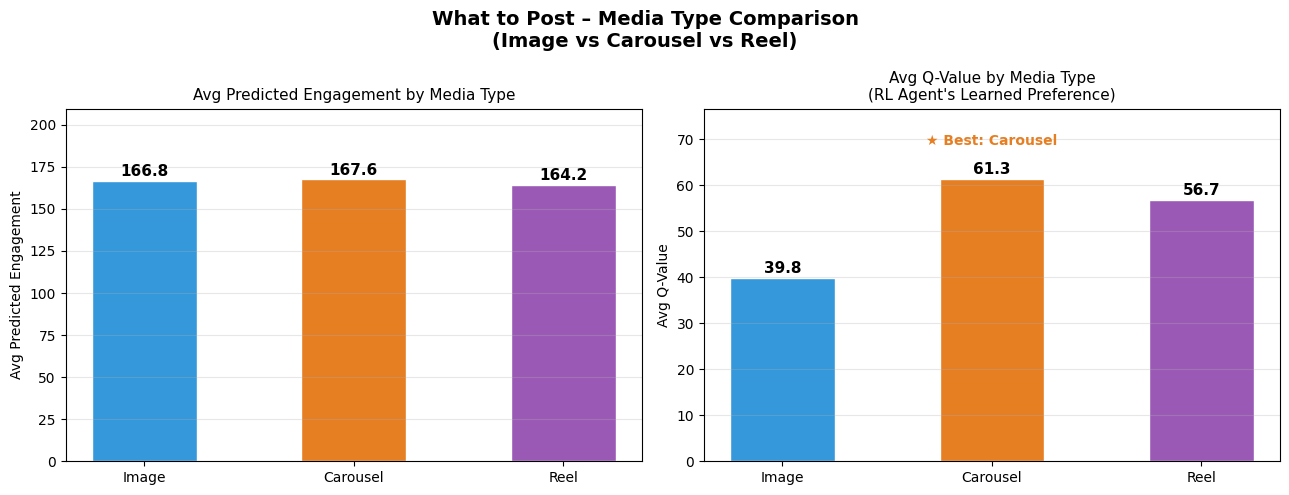


Media Type Comparison Summary:
Media Type     Avg Engagement   Avg Q-Value   Recommended?
---------------------------------------------------------
Image                   166.8          39.8               
Carousel                167.6          61.3          ★ YES
Reel                    164.2          56.7               

→ The RL agent recommends posting as a 'Carousel' for maximum engagement.


In [8]:
media_labels  = [MEDIA_TYPE_DECODER[m].capitalize() for m in range(N_MEDIA)]
MEDIA_COLORS  = ["#3498DB", "#E67E22", "#9B59B6"]   # image=blue, carousel=orange, reel=purple

# ── 1. Average predicted engagement per media type (across all hashtag×time combos) ──
avg_engagement_by_media = []
for m in range(N_MEDIA):
    vals = [REWARD_TABLE[(h, t, m)] for h in range(N_HASHTAGS) for t in range(N_TIMES)]
    avg_engagement_by_media.append(np.mean(vals))

# ── 2. Average Q-value per media type (what the RL agent learned) ─────────────
avg_q_by_media = []
for m in range(N_MEDIA):
    action_indices = [i for i, (h, t, mv) in enumerate(ACTIONS) if mv == m]
    q_vals = agent.Q[:, action_indices].mean()   # mean over all states & actions of this media type
    avg_q_by_media.append(q_vals)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("What to Post – Media Type Comparison\n(Image vs Carousel vs Reel)",
             fontsize=14, fontweight="bold")

# --- Left: predicted engagement ---
bars1 = axes[0].bar(media_labels, avg_engagement_by_media, color=MEDIA_COLORS,
                    edgecolor="white", width=0.5)
axes[0].set_title("Avg Predicted Engagement by Media Type", fontsize=11)
axes[0].set_ylabel("Avg Predicted Engagement")
axes[0].set_ylim(0, max(avg_engagement_by_media) * 1.25)
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, avg_engagement_by_media):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# --- Right: average Q-value ---
bars2 = axes[1].bar(media_labels, avg_q_by_media, color=MEDIA_COLORS,
                    edgecolor="white", width=0.5)
axes[1].set_title("Avg Q-Value by Media Type\n(RL Agent's Learned Preference)", fontsize=11)
axes[1].set_ylabel("Avg Q-Value")
axes[1].set_ylim(0, max(avg_q_by_media) * 1.25)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, avg_q_by_media):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Winner annotation
winner_idx = int(np.argmax(avg_q_by_media))
axes[1].annotate(
    f"★ Best: {media_labels[winner_idx]}",
    xy=(winner_idx, avg_q_by_media[winner_idx]),
    xytext=(winner_idx, avg_q_by_media[winner_idx] * 1.12),
    ha="center", fontsize=10, color=MEDIA_COLORS[winner_idx], fontweight="bold"
)

plt.tight_layout()
plt.savefig("plot_media_type_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nMedia Type Comparison Summary:")
print(f"{'Media Type':<12} {'Avg Engagement':>16} {'Avg Q-Value':>13} {'Recommended?':>14}")
print("-" * 57)
for m in range(N_MEDIA):
    rec = "★ YES" if m == winner_idx else ""
    print(f"{media_labels[m]:<12} {avg_engagement_by_media[m]:>16.1f} {avg_q_by_media[m]:>13.1f} {rec:>14}")

print(f"\n→ The RL agent recommends posting as a '{media_labels[winner_idx]}' "
      f"for maximum engagement.")

## 6.4 Policy Map

The **greedy policy** selects the action with the highest Q-value in each state (epsilon = 0, no exploration).

The table below shows, for every (hashtag, time-of-day, media-type) starting state, which full combination the agent recommends — i.e. the complete 3-part posting strategy learned by the agent.

In [9]:
rows = []
for h in range(N_HASHTAGS):
    for t in range(N_TIMES):
        for m in range(N_MEDIA):
            state         = state_index(h, t, m)
            best_action   = int(np.argmax(agent.Q[state]))
            bh, bt, bm    = ACTIONS[best_action]
            expected_eng  = REWARD_TABLE[(bh, bt, bm)]

            rows.append({
                "Current Hashtag"    : HASHTAG_DECODER[h],
                "Current Time"       : TIME_DECODER[t],
                "Current Media Type" : MEDIA_TYPE_DECODER[m].capitalize(),
                "→ Best Hashtag"     : HASHTAG_DECODER[bh],
                "→ Best Time"        : TIME_DECODER[bt],
                "→ Best Media Type"  : MEDIA_TYPE_DECODER[bm].capitalize(),
                "Expected Engagement": round(expected_eng, 1),
            })

policy_df = pd.DataFrame(rows)

print("Greedy Policy Map (first 24 rows shown):")
print(policy_df.head(24).to_string(index=False))

# ── Policy summary — most-recommended (media, time) pair per hashtag ──────────
print("\n── Best action per hashtag (highest Q-value state as starting point) ──")
for h in range(N_HASHTAGS):
    # Take the state whose greedy action yields the highest expected engagement
    best_eng  = -np.inf
    best_info = None
    for t in range(N_TIMES):
        for m in range(N_MEDIA):
            state        = state_index(h, t, m)
            best_action  = int(np.argmax(agent.Q[state]))
            bh, bt, bm   = ACTIONS[best_action]
            eng          = REWARD_TABLE[(bh, bt, bm)]
            if eng > best_eng:
                best_eng  = eng
                best_info = (bh, bt, bm)
    bh, bt, bm = best_info
    print(f"  {HASHTAG_DECODER[h]:<20}  → post {MEDIA_TYPE_DECODER[bm]:<9} in the {TIME_DECODER[bt]}  "
          f"(est. engagement: {best_eng:.0f})")

Greedy Policy Map (first 24 rows shown):
Current Hashtag Current Time Current Media Type  → Best Hashtag → Best Time → Best Media Type  Expected Engagement
#AppleEvent2025      morning              Image   #MadeByGoogle     morning          Carousel                166.1
#AppleEvent2025      morning           Carousel   #MadeByGoogle     morning              Reel                178.6
#AppleEvent2025      morning               Reel #AppleEvent2025   afternoon          Carousel                169.2
#AppleEvent2025    afternoon              Image   #MadeByGoogle       night              Reel                169.1
#AppleEvent2025    afternoon           Carousel  #GalaxyS25Edge     morning              Reel                174.3
#AppleEvent2025    afternoon               Reel      #GalaxyS25     morning             Image                176.0
#AppleEvent2025      evening              Image   #MadeByGoogle     morning              Reel                178.6
#AppleEvent2025      evening           

## 7. Final Recommendation

The Q-Learning agent has been trained over **500 episodes** on a **48-action space** (4 hashtags × 4 time slots × 3 media types).

The cell below identifies the single best (hashtag, time-of-day, media type) combination — the global optimum across all 48 actions — and prints a clear, human-readable posting strategy recommendation.

In [10]:
# ── Global best action across all 48 actions ─────────────────────────────────
# Average Q-value over all states for each action, then pick the top action
avg_q_per_action = agent.Q.mean(axis=0)        # shape (48,)
best_action_idx  = int(np.argmax(avg_q_per_action))

h_best, t_best, m_best = ACTIONS[best_action_idx]

best_hashtag    = HASHTAG_DECODER[h_best]
best_time       = TIME_DECODER[t_best]
best_media_type = MEDIA_TYPE_DECODER[m_best].capitalize()
best_engagement = REWARD_TABLE[(h_best, t_best, m_best)]

# ── Print recommendation ──────────────────────────────────────────────────────
print("=" * 62)
print("   INSTAGRAM POSTING STRATEGY – RL RECOMMENDATION")
print("=" * 62)
print(f"  Hashtag      : {best_hashtag}")
print(f"  Time of Day  : {best_time.capitalize()}")
print(f"  Media Type   : {best_media_type}")
print(f"  Est. Engage. : {best_engagement:.0f} interactions")
print("=" * 62)
print()
print(f"  The agent recommends posting a {best_media_type.lower()} content")
print(f"  using {best_hashtag} during the {best_time} for")
print(f"  maximum predicted engagement (~{best_engagement:.0f} interactions).")
print()
print("  Top 5 (hashtag × time × media type) combinations by Q-value:")
top5 = sorted(
    [(action_idx, avg_q_per_action[action_idx]) for action_idx in range(N_ACTIONS)],
    key=lambda x: x[1], reverse=True
)[:5]
print(f"  {'Rank':<5} {'Hashtag':<22} {'Time':<12} {'Media':<10} {'Avg Q':>8}")
print(f"  {'-'*5} {'-'*22} {'-'*12} {'-'*10} {'-'*8}")
for rank, (idx, qval) in enumerate(top5, start=1):
    h, t, m = ACTIONS[idx]
    eng     = REWARD_TABLE[(h, t, m)]
    print(f"  {rank:<5} {HASHTAG_DECODER[h]:<22} {TIME_DECODER[t]:<12} "
          f"{MEDIA_TYPE_DECODER[m].capitalize():<10} {qval:>8.1f}")

print()
print("Training summary:")
print(f"  Episodes        : {EPISODES}")
print(f"  Steps/episode   : {STEPS}")
print(f"  Final epsilon   : {agent.epsilon:.4f}")

   INSTAGRAM POSTING STRATEGY – RL RECOMMENDATION
  Hashtag      : #MadeByGoogle
  Time of Day  : Morning
  Media Type   : Reel
  Est. Engage. : 179 interactions

  The agent recommends posting a reel content
  using #MadeByGoogle during the morning for
  maximum predicted engagement (~179 interactions).

  Top 5 (hashtag × time × media type) combinations by Q-value:
  Rank  Hashtag                Time         Media         Avg Q
  ----- ---------------------- ------------ ---------- --------
  1     #MadeByGoogle          morning      Reel          176.2
  2     #AppleEvent2025        morning      Carousel      150.2
  3     #GalaxyS25             morning      Image         137.9
  4     #AppleEvent2025        afternoon    Carousel      114.6
  5     #GalaxyS25Edge         morning      Reel          110.2

Training summary:
  Episodes        : 500
  Steps/episode   : 10
  Final epsilon   : 0.0816
